<a href="https://colab.research.google.com/github/Pavithraanarayanan/github1/blob/main/skillfied.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("data.csv")

# Preview data
print(df.head())

# Dataset info
print(df.info())

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

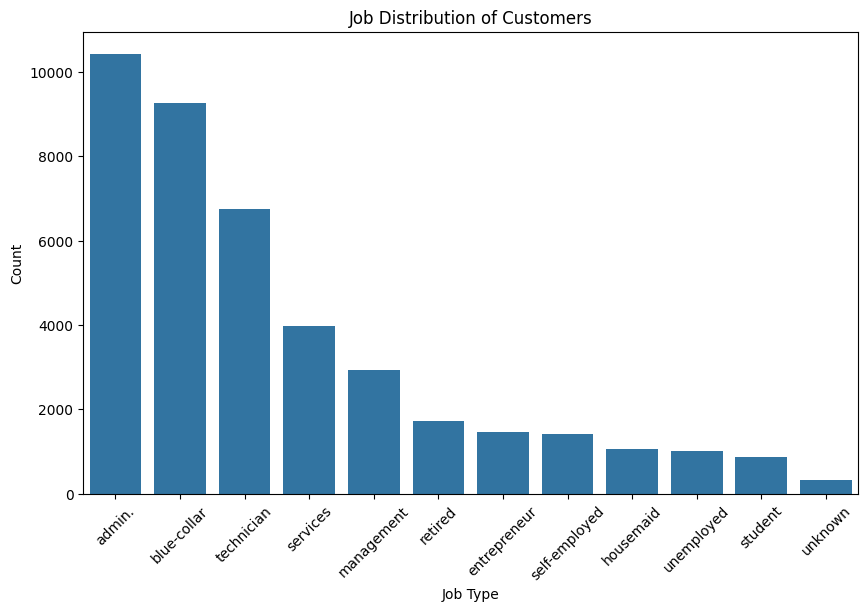

In [2]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='job', order=df['job'].value_counts().index)

plt.xticks(rotation=45)
plt.title("Job Distribution of Customers")
plt.xlabel("Job Type")
plt.ylabel("Count")

plt.show()

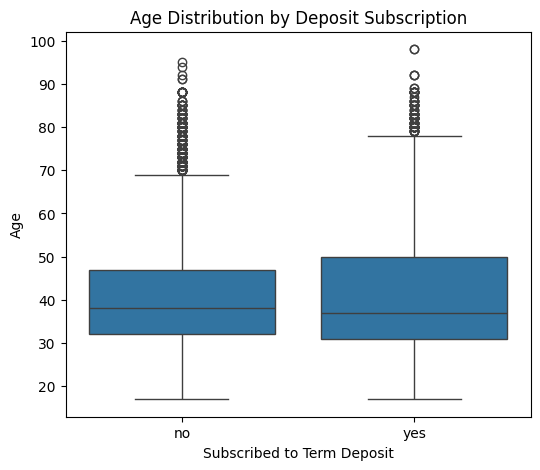

In [3]:
plt.figure(figsize=(6,5))

sns.boxplot(data=df, x='y', y='age')

plt.title("Age Distribution by Deposit Subscription")
plt.xlabel("Subscribed to Term Deposit")
plt.ylabel("Age")

plt.show()

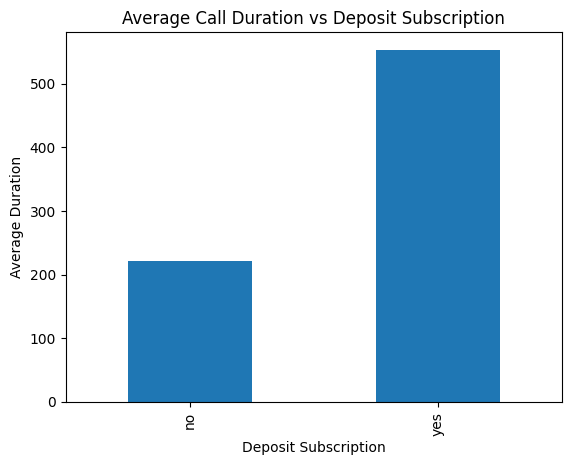

In [4]:
avg_balance = df.groupby('y')['duration'].mean()

avg_balance.plot(kind='bar')

plt.title("Average Call Duration vs Deposit Subscription")
plt.xlabel("Deposit Subscription")
plt.ylabel("Average Duration")

plt.show()

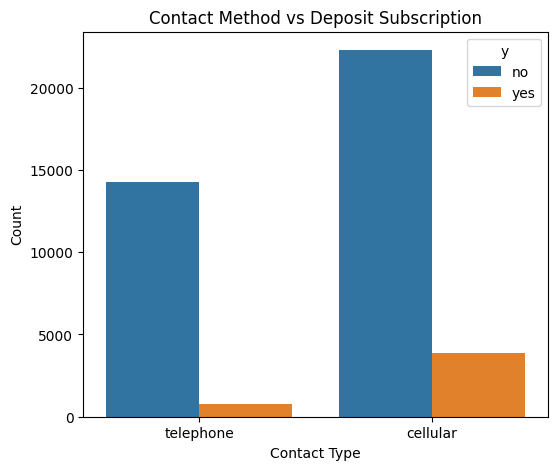

In [5]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x='contact', hue='y')

plt.title("Contact Method vs Deposit Subscription")
plt.xlabel("Contact Type")
plt.ylabel("Count")

plt.show()

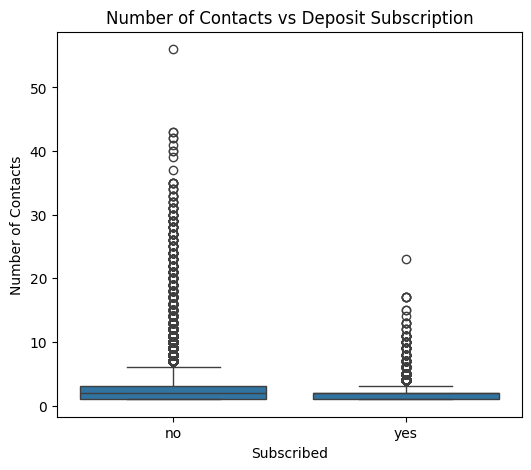

In [6]:
plt.figure(figsize=(6,5))

sns.boxplot(data=df, x='y', y='campaign')

plt.title("Number of Contacts vs Deposit Subscription")
plt.xlabel("Subscribed")
plt.ylabel("Number of Contacts")

plt.show()

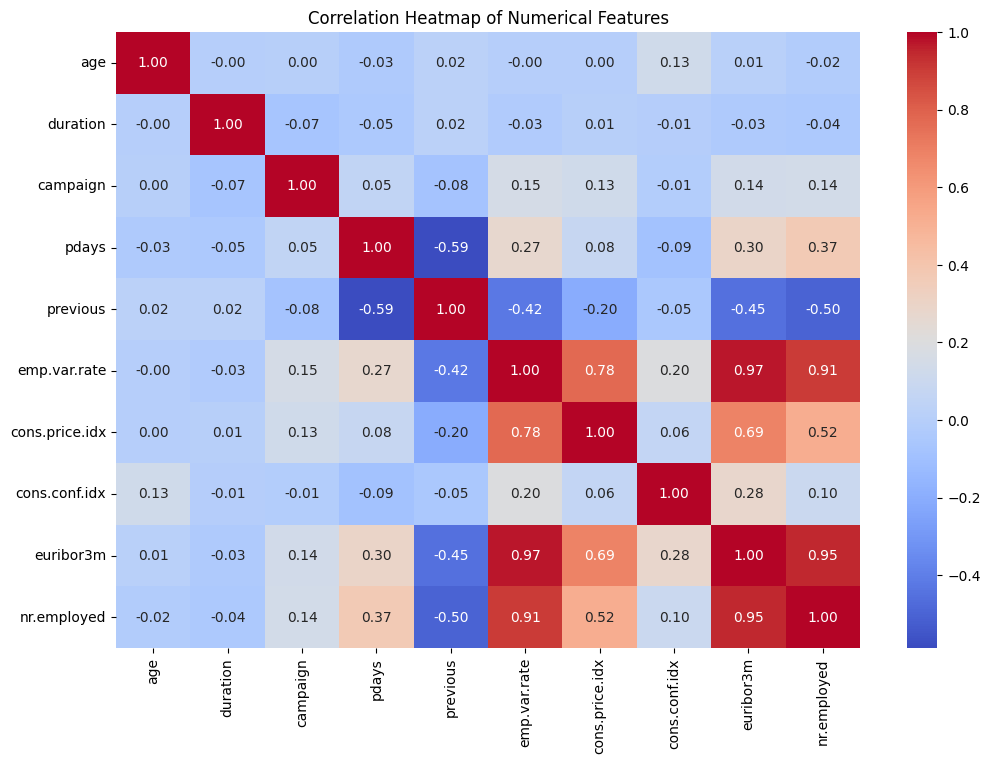

In [8]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

In [9]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

le = LabelEncoder()

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [11]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.9104151493080845
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7303
           1       0.67      0.42      0.51       935

    accuracy                           0.91      8238
   macro avg       0.80      0.69      0.73      8238
weighted avg       0.90      0.91      0.90      8238



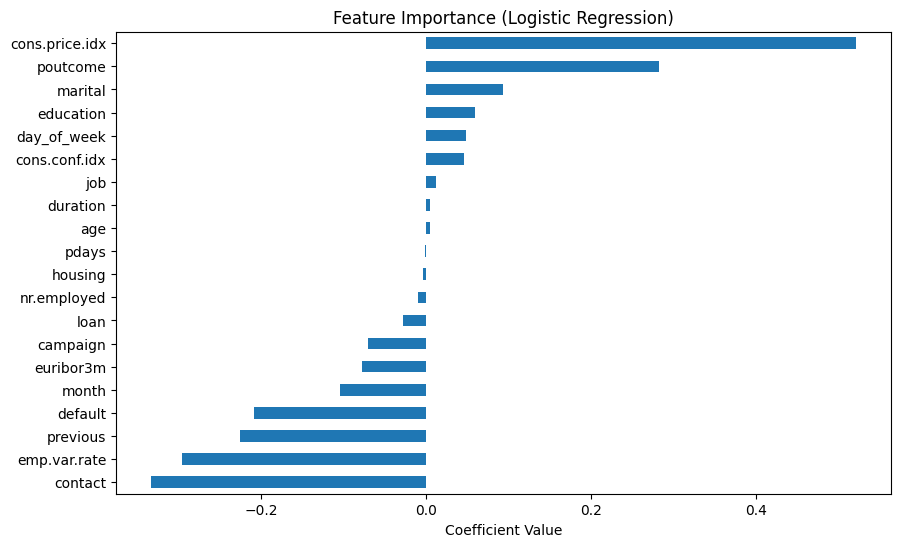

In [12]:
importance = pd.Series(model.coef_[0], index=X.columns)

importance.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient Value")

plt.show()